<a href="https://colab.research.google.com/github/shizatari/AI-Based-Pneumonia-Detection-from-Chest-X-Ray-Images-Using-CNN-Grad-CAM-with-Python-/blob/main/ChangedProject_Pneumonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing the necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
import os
import tensorflow as tf

# Pneumonia DataSet

In [3]:
labels = ['PNEUMONIA','NORMAL']
img_resize = 150

def get_data(dir):
  data = []
  for label in labels:
    path = os.path.join(dir, label)
    class_num = labels.index(label)

    for img in os.listdir(path):
      try:
        if img.endswith('jpeg'):
          img_arr = cv2.imread(os.path.join(path,img), cv2.IMREAD_GRAYSCALE)
          resized_arr = cv2.resize(img_arr, (img_resize, img_resize))
          data.append([resized_arr, class_num])
      except Exception as e:
        print(e)
  return np.array(data,dtype= 'object')




In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
train = get_data('/content/drive/MyDrive/Image Processing Project/ChestXRay2017/chest_xray/train')
test = get_data('/content/drive/MyDrive/Image Processing Project/ChestXRay2017/chest_xray/test')
val = get_data('/content/drive/MyDrive/Image Processing Project/ChestXRay2017/chest_xray/val')

## Data Visualization and Preprocessing

<Axes: xlabel='count'>

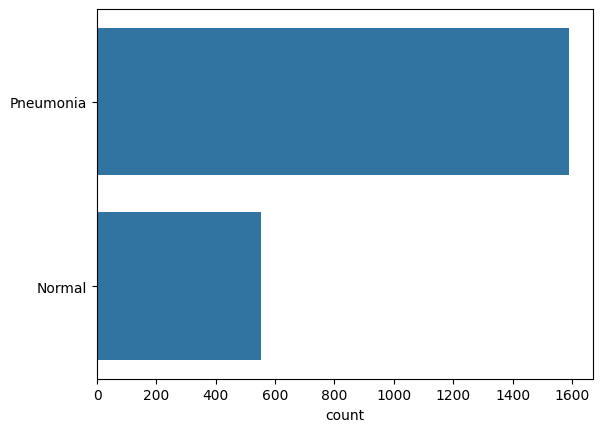

In [6]:
l = []
for i in train:
  if (i[1] == 0):
    l.append('Pneumonia')
  else:
    l.append('Normal')

sns.countplot(l)

Text(0.5, 1.0, 'NORMAL')

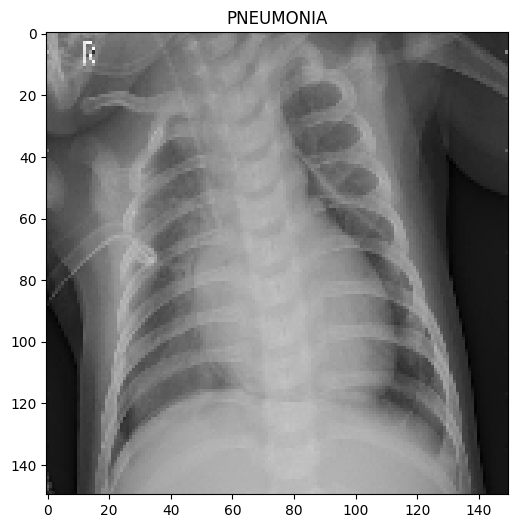

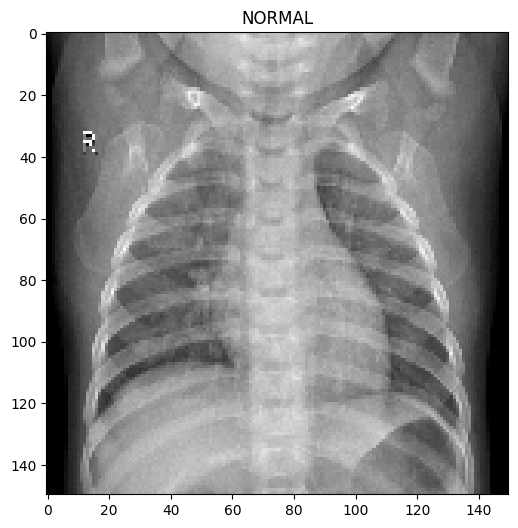

In [7]:
plt.figure(figsize=(6,6))

plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))

plt.imshow(train[-11][0], cmap='gray')
plt.title(labels[train[-11][1]])

In [8]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feat, label in train:
  x_train.append(feat)
  y_train.append(label)

for feat,label in val:
  x_val.append(feat)
  y_val.append(label)

for feat, label in test:
  x_test.append(feat)
  y_test.append(label)

In [9]:
#Normalize the data
x_train = np.array(x_train)/255
x_val = np.array(x_val)/255
x_test = np.array(x_test)/255

In [10]:
x_train

array([[[0.61960784, 0.61960784, 0.62745098, ..., 0.17254902,
         0.18039216, 0.17647059],
        [0.59607843, 0.61176471, 0.65098039, ..., 0.18039216,
         0.18823529, 0.18039216],
        [0.58823529, 0.61568627, 0.63529412, ..., 0.18039216,
         0.18823529, 0.18823529],
        ...,
        [0.38823529, 0.21568627, 0.0745098 , ..., 0.08235294,
         0.08235294, 0.08235294],
        [0.31764706, 0.11372549, 0.05490196, ..., 0.08235294,
         0.08235294, 0.08235294],
        [0.15686275, 0.20784314, 0.14117647, ..., 0.08235294,
         0.08235294, 0.08235294]],

       [[0.10196078, 0.10196078, 0.10196078, ..., 0.1372549 ,
         0.12156863, 0.10196078],
        [0.09803922, 0.09803922, 0.10196078, ..., 0.1372549 ,
         0.11764706, 0.09019608],
        [0.09803922, 0.10196078, 0.10588235, ..., 0.1372549 ,
         0.10980392, 0.07843137],
        ...,
        [0.13333333, 0.12156863, 0.12941176, ..., 0.34509804,
         0.29803922, 0.23137255],
        [0.1

In [11]:
x_train = x_train.reshape(-1,img_resize, img_resize,1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1,img_resize,img_resize,1)
y_val = np.array(y_val)


x_test = x_test.reshape(-1,img_resize,img_resize,1)
y_test = np.array(y_test)

In [12]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.6739949748743719), 1: np.float64(1.9368231046931408)}


In [13]:
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=30,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.2,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)

#Training the model

In [14]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Dropout, Flatten, Dense

inputs = tf.keras.Input(shape=(150, 150, 1))

x = Conv2D(32, (3,3), activation='relu', padding='same', name="conv1")(inputs)
x = BatchNormalization()(x)
x = MaxPool2D()(x)

x = Conv2D(64, (3,3), activation='relu', padding='same', name="conv2")(x)
x = Dropout(0.1)(x)
x = BatchNormalization()(x)
x = MaxPool2D()(x)

x = Conv2D(64, (3,3), activation='relu', padding='same', name="conv3")(x)
x = BatchNormalization()(x)
x = MaxPool2D()(x)

x = Conv2D(128, (3,3), activation='relu', padding='same', name="conv4")(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)
x = MaxPool2D()(x)

x = Conv2D(256, (3,3), activation='relu', padding='same', name="conv5")(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)
x = MaxPool2D()(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)

outputs = Dense(1, activation=None)(x)   # ✅ FIXED LINE

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='rmsprop',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 9, 9, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 9, 9, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 951,489 (3.63 MB)

 Trainable params: 950,401 (3.63 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [15]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',patience=2,verbose=1,factor=0.3,min_lr=0.000001)

In [18]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    verbose=1,
    factor=0.3,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [19]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(x_val, y_val),
    callbacks=[learning_rate_reduction, early_stop],
    class_weight=class_weights
)

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 30s 258ms/step - accuracy: 0.7973 - loss: 0.8722 - val_accuracy: 0.7424 - val_loss: 4.4700 - learning_rate: 0.0010
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.8430 - loss: 0.4103 - val_accuracy: 0.7424 - val_loss: 19.9602 - learning_rate: 0.0010
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8513 - loss: 0.4263
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.8686 - loss: 0.4093 - val_accuracy: 0.7424 - val_loss: 7.4212 - learning_rate: 0.0010
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.9045 - loss: 0.2426 - val_accuracy: 0.7424 - val_loss: 4.8790 - learning_rate: 3.0000e-04
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9200 - loss: 0.2376
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9199 - loss: 0.2298 - va

In [20]:
model.evaluate(x_test,y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8397 - loss: 0.5401


[0.5400932431221008, 0.8397436141967773]

In [21]:
print(f"Loss of the model is {model.evaluate(x_test,y_test)[0]}")
print(f"Accuracy of the model is {model.evaluate(x_test,y_test)[1]*100} %")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8397 - loss: 0.5401
Loss of the model is 0.5400932431221008
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8397 - loss: 0.5401
Accuracy of the model is 83.97436141967773 %


# Analyse Model Performance

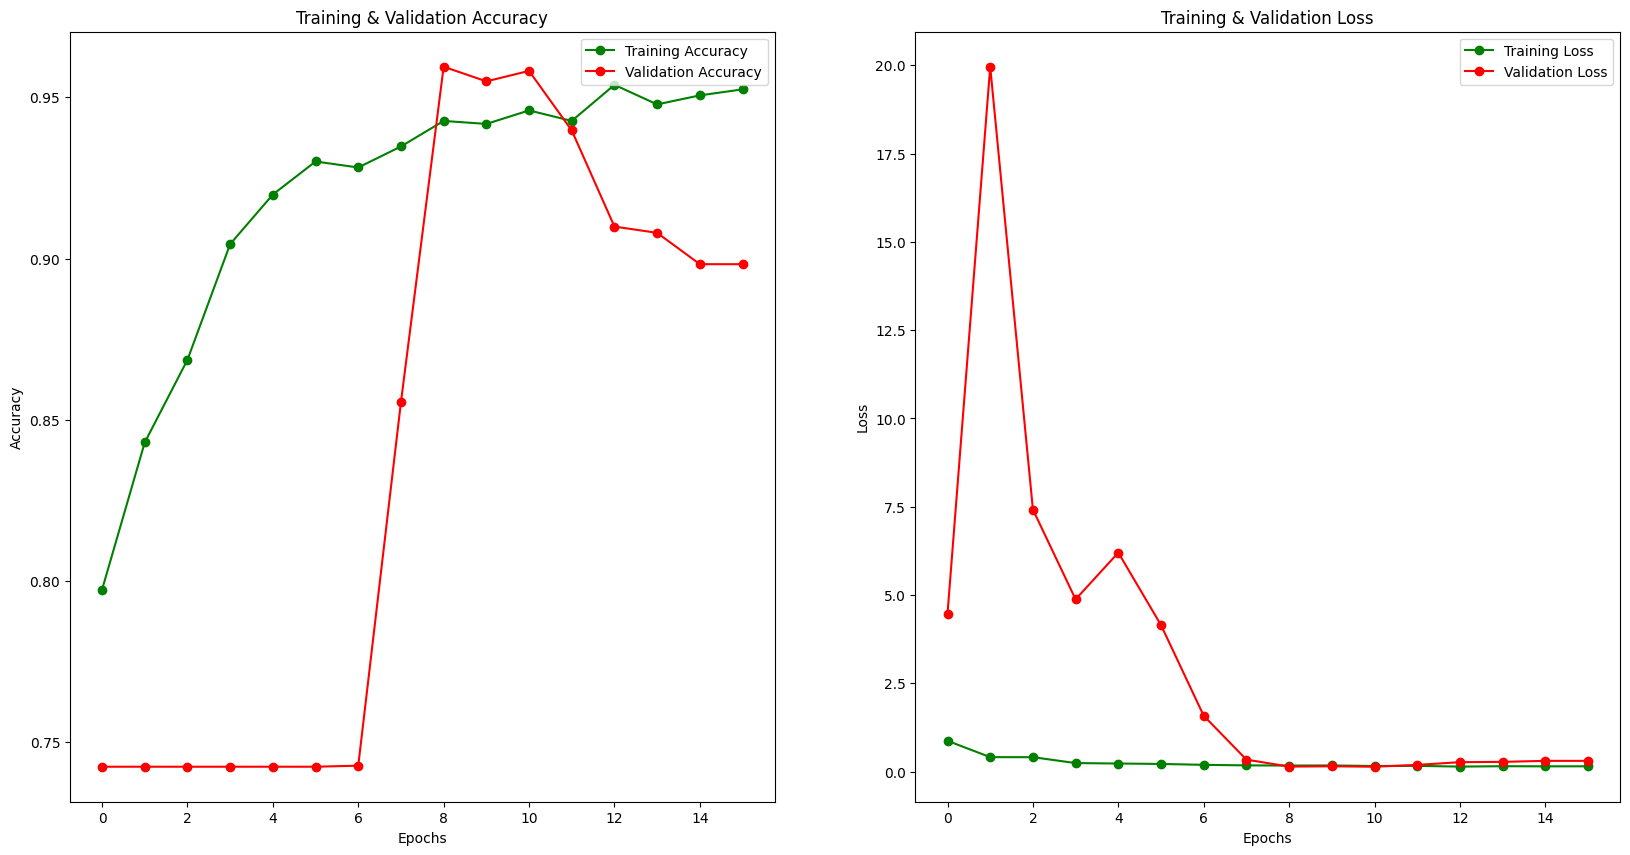

In [22]:
epochs = range(len(history.history['accuracy']))
fig, ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.set_size_inches(20,10)

ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')


ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


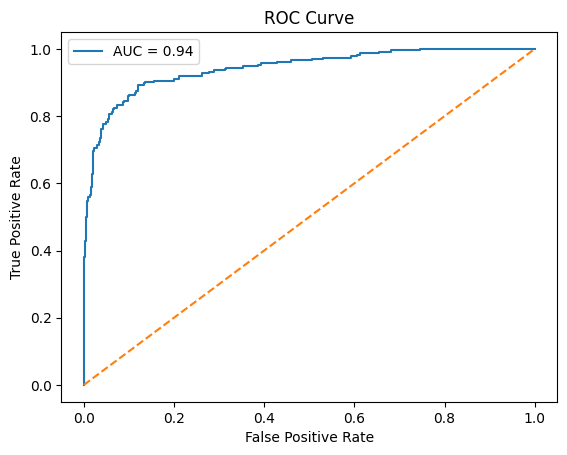

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [23]:
predictions = (model.predict(x_test) > 0.5).astype('int32')
from sklearn.metrics import roc_curve, auc

y_pred_prob = model.predict(x_test)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

In [24]:
print(classification_report(y_test, predictions, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.80      0.98      0.88       390
   Normal (Class 1)       0.95      0.60      0.74       234

           accuracy                           0.84       624
          macro avg       0.88      0.79      0.81       624
       weighted avg       0.86      0.84      0.83       624



20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


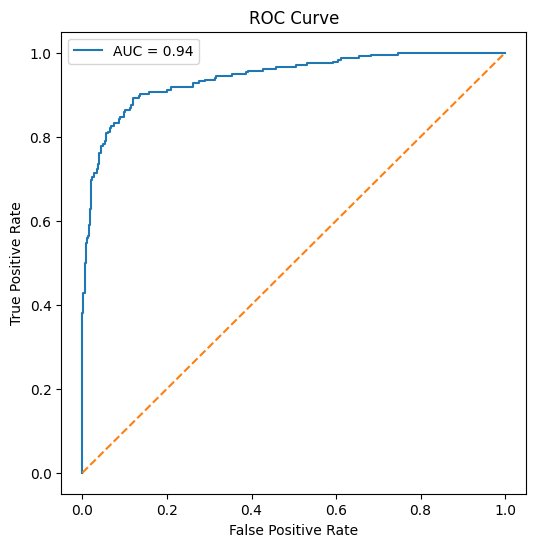

In [25]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = model.predict(x_test)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [26]:
cm = confusion_matrix(y_test,predictions)

In [27]:
cm

array([[383,   7],
       [ 93, 141]])

In [28]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

#Some Correctly Predicted Classes

---



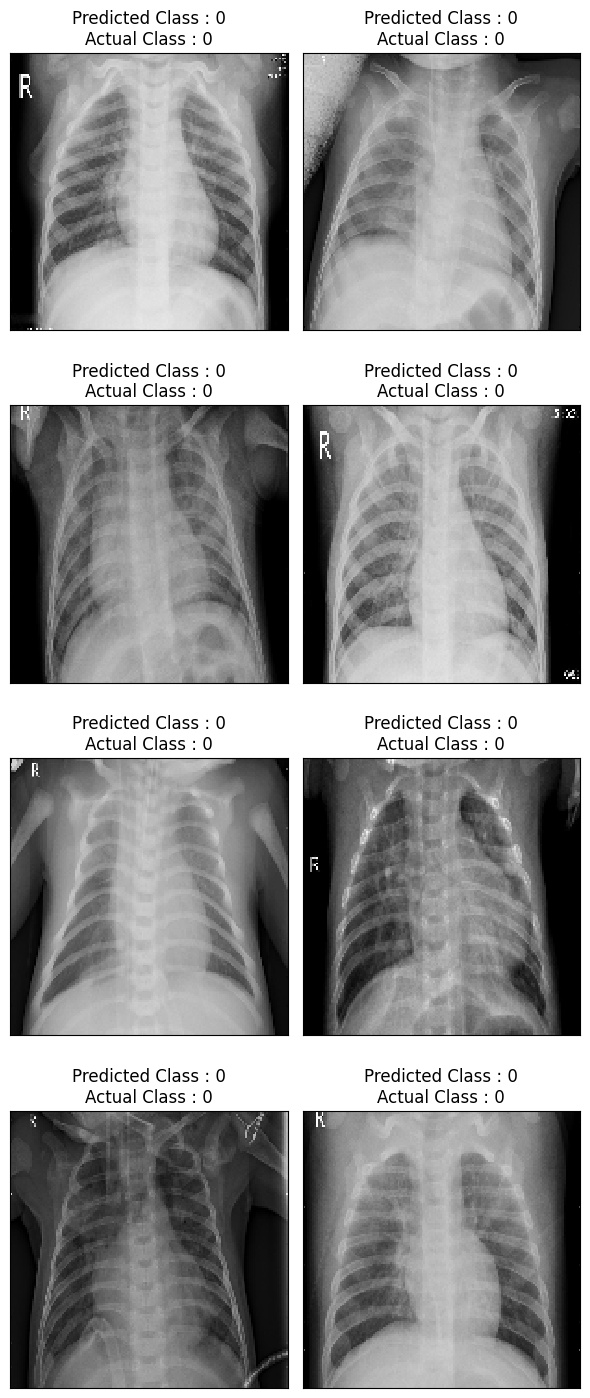

In [29]:
i = 0
plt.figure(figsize=(6,15))
for c in correct[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1

#Some Incorrectly Predicted Classes

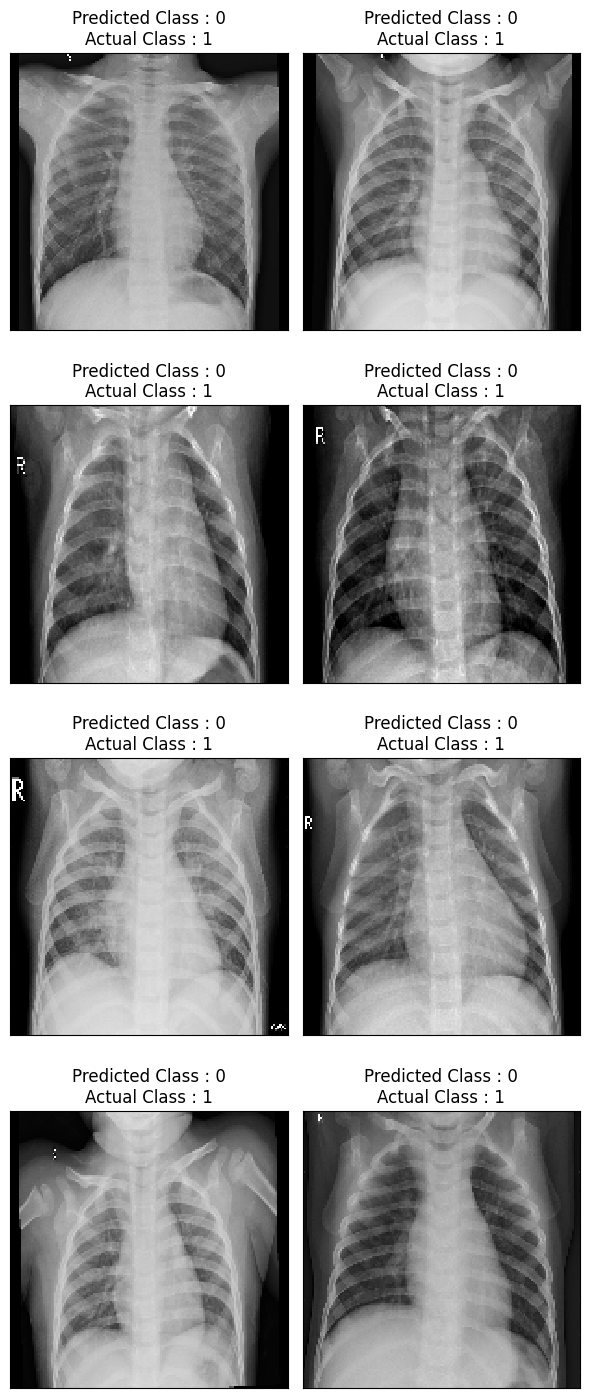

In [30]:
i = 0
plt.figure(figsize=(6,15))
for c in incorrect[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1

### Grad-CAM

In [31]:
import numpy as np
import tensorflow as tf

def make_gradcam_heatmap(model, img, layer_name="conv5"):
    img = tf.convert_to_tensor(np.expand_dims(img, axis=0), dtype=tf.float32)

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img, training=False)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [32]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def overlay_heatmap(img, heatmap, alpha=0.4):
    img = (img * 255).astype(np.uint8)

    # ensure 3-channel image
    if len(img.shape) == 2 or img.shape[-1] == 1:
        img = cv2.cvtColor(img.squeeze(), cv2.COLOR_GRAY2BGR)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

    return overlay

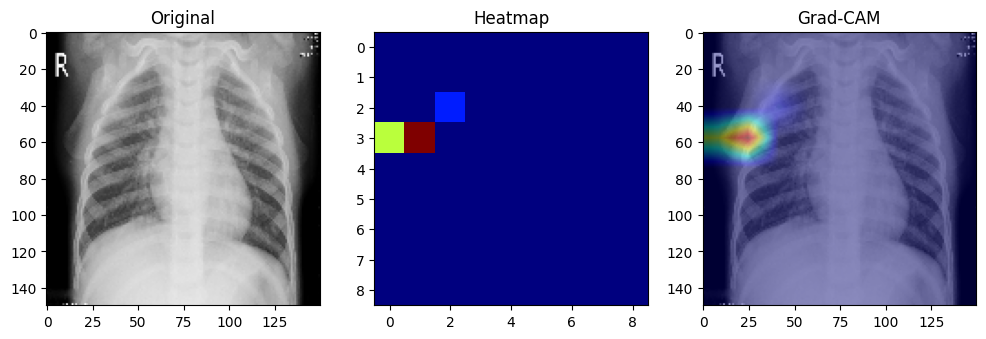

In [33]:
index = 10
img = x_test[index]

heatmap = make_gradcam_heatmap(model, img, "conv5")

overlay = overlay_heatmap(img, heatmap)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img.squeeze(), cmap='gray')

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap, cmap='jet')

plt.subplot(1,3,3)
plt.title("Grad-CAM")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))

plt.show()

In [34]:
pred = model.predict(np.expand_dims(x_test[10], axis=0))
print("Prediction:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
Prediction: [[-5.3937845]]


In [35]:
print("Max heatmap value:", np.max(heatmap))
print("Min heatmap value:", np.min(heatmap))

Max heatmap value: 0.99999887
Min heatmap value: 0.0
